In [6]:
#import pandas as pd
import pandas as pd

In [7]:
#create MSFT_Tech dataframe
MSFT_Tech=pd.read_excel("C:\\Users\\Dell\\Desktop\\Portfolio Mgt\\pyt\\MSFT.xlsx")

In [8]:
MSFT_Tech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       61 non-null     datetime64[ns]
 1   Open       61 non-null     float64       
 2   High       61 non-null     float64       
 3   Low        61 non-null     float64       
 4   Close      61 non-null     float64       
 5   Adj Close  61 non-null     float64       
 6   Volume     61 non-null     int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 3.5 KB


In [9]:
#create BLCN_ETF dataframe
BLCN_ETF=pd.read_excel("C:\\Users\\Dell\\Desktop\\Portfolio Mgt\\pyt\\BLCN.xlsx")

In [10]:
BLCN_ETF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       61 non-null     datetime64[ns]
 1   Open       61 non-null     float64       
 2   High       61 non-null     float64       
 3   Low        61 non-null     float64       
 4   Close      61 non-null     float64       
 5   Adj Close  61 non-null     float64       
 6   Volume     61 non-null     int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 3.5 KB


In [11]:
#create NDVA_Stock dataframe
NDVA_Stock=pd.read_excel("C:\\Users\\Dell\\Desktop\\Portfolio Mgt\\pyt\\NVDA.xlsx")

In [12]:
NDVA_Stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       61 non-null     datetime64[ns]
 1   Open       61 non-null     float64       
 2   High       61 non-null     float64       
 3   Low        61 non-null     float64       
 4   Close      61 non-null     float64       
 5   Adj Close  61 non-null     float64       
 6   Volume     61 non-null     int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 3.5 KB


In [13]:
#create PLD_RealEstate dataframe
PLD_RealEstate=pd.read_excel("C:\\Users\\Dell\\Desktop\\Portfolio Mgt\\pyt\\PLD.xlsx")

In [14]:
PLD_RealEstate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       61 non-null     datetime64[ns]
 1   Open       61 non-null     float64       
 2   High       61 non-null     float64       
 3   Low        61 non-null     float64       
 4   Close      61 non-null     float64       
 5   Adj Close  61 non-null     float64       
 6   Volume     61 non-null     int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 3.5 KB


In [28]:
# Rename the 'Adj Close' columns to identify each stock
BLCN_ETF.rename(columns={'Adj Close': 'BLCN_Adj_Close'}, inplace=True)
NDVA_Stock.rename(columns={'Adj Close': 'NDVA_Adj_Close'}, inplace=True)
PLD_RealEstate.rename(columns={'Adj Close': 'PLD_Adj_Close'}, inplace=True)
MSFT_Tech.rename(columns={'Adj Close': 'MSFT_Adj_Close'}, inplace=True)

In [29]:
# Merge DataFrames on 'Date' with specified suffixes
merged_data = pd.merge(BLCN_ETF[['Date', 'BLCN_Adj_Close']], NDVA_Stock[['Date', 'NDVA_Adj_Close']], on='Date', how='outer')
merged_data = pd.merge(merged_data, PLD_RealEstate[['Date', 'PLD_Adj_Close']], on='Date', how='outer')
merged_data = pd.merge(merged_data, MSFT_Tech[['Date', 'MSFT_Adj_Close']], on='Date', how='outer')

In [30]:
# Convert 'Date' column to datetime format if it's not already
merged_data['Date'] = pd.to_datetime(merged_data['Date'])

In [31]:
# Sort the merged DataFrame by 'Date'
merged_data = merged_data.sort_values(by='Date')

In [32]:
merged_data.head(2)

,Date,BLCN_Adj_Close,NDVA_Adj_Close,PLD_Adj_Close,MSFT_Adj_Close
0,2019-07-01,22.585211,4.193791,70.980629,129.960083
1,2019-08-01,21.835892,4.163713,73.631050,131.476517


In [33]:
# Calculate the percentage change in 'Adj Close' prices for each stock
merged_data['BLCN_HPY_Returns'] = merged_data['BLCN_Adj_Close'].pct_change() * 100
merged_data['NDVA_HPY_Returns'] = merged_data['NDVA_Adj_Close'].pct_change() * 100
merged_data['PLD_HPY_Returns'] = merged_data['PLD_Adj_Close'].pct_change() * 100
merged_data['MSFT_HPY_Returns'] = merged_data['MSFT_Adj_Close'].pct_change() * 100

# Display the DataFrame with percentage changes
print(merged_data[['Date', 'BLCN_HPY_Returns', 'NDVA_HPY_Returns', 'PLD_HPY_Returns', 'MSFT_HPY_Returns']])

         Date  BLCN_HPY_Returns  NDVA_HPY_Returns  PLD_HPY_Returns  \
0  2019-07-01               NaN               NaN              NaN   
1  2019-08-01         -3.317742         -0.717203         3.734006   
2  2019-09-01          1.385828          4.019105         1.913445   
3  2019-10-01          3.762016         15.482248         3.622227   
4  2019-11-01          4.011361          7.820154         4.318614   
..        ...               ...               ...              ...   
56 2024-03-01          7.954108         14.212758        -2.288588   
57 2024-04-01        -12.607523         -4.371532       -21.052971   
58 2024-05-01          3.572885         26.887113         8.270447   
59 2024-06-01          6.350438         15.010985        -0.072396   
60 2024-06-26          0.465738         -1.712921         0.862298   

    MSFT_HPY_Returns  
0                NaN  
1           1.166846  
2           1.184491  
3           3.121601  
4           5.586974  
..               ... 

In [34]:
#import numpy as np
import numpy as np

In [35]:
# Compute the average monthly return
average_BLCN_Returns = np.mean(merged_data['BLCN_HPY_Returns'])
average_NDVA_Returns = np.mean(merged_data['NDVA_HPY_Returns'])
average_PLD_Returns = np.mean(merged_data['PLD_HPY_Returns'])
average_MSFT_Returns =np.mean(merged_data['MSFT_HPY_Returns'])

# Display the results
print(f"Average_BLCN_Returns: {average_BLCN_Returns:.2f}")
print(f"Average_NVDA_Returns: {average_NDVA_Returns:.2f}")
print(f"Average_PLD_Returns: {average_PLD_Returns:.2f}")
print(f"Average_MSFT_Returns: {average_MSFT_Returns:.2f}")

Average_BLCN_Returns: 0.67
Average_NVDA_Returns: 6.80
Average_PLD_Returns: 1.09
Average_MSFT_Returns: 2.29


In [36]:
# Compute the variance for each stock's returns
variance_BLCN = np.var(merged_data['BLCN_HPY_Returns'])
variance_NDVA = np.var(merged_data['NDVA_HPY_Returns'])
variance_PLD = np.var(merged_data['PLD_HPY_Returns'])
variance_MSFT = np.var(merged_data['MSFT_HPY_Returns'])

print(f"Variance BLCN Returns: {variance_BLCN:.2f}")
print(f"Variance NDVA Returns: {variance_NDVA:.2f}")
print(f"Variance PLD Returns: {variance_PLD:.2f}")
print(f"Variance MSFT Returns: {variance_MSFT:.2f}")

Variance BLCN Returns: 73.04
Variance NDVA Returns: 203.06
Variance PLD Returns: 68.01
Variance MSFT Returns: 39.19


In [39]:
# Compute the variance for each stock's returns
std_BLCN = np.std(merged_data['BLCN_HPY_Returns'])
std_NDVA = np.std(merged_data['NDVA_HPY_Returns'])
sdt_PLD = np.std(merged_data['PLD_HPY_Returns'])
std_MSFT = np.std(merged_data['MSFT_HPY_Returns'])

print(f"std BLCN Returns: {std_BLCN:.2f}")
print(f"std NDVA Returns: {std_NDVA:.2f}")
print(f"std PLD Returns: {sdt_PLD:.2f}")
print(f"std MSFT Returns: {std_MSFT:.2f}")

std BLCN Returns: 8.55
std NDVA Returns: 14.25
std PLD Returns: 8.25
std MSFT Returns: 6.26


In [40]:
# Investment amounts in each asset
investment_BLCN = 150000
investment_NDVA = 200000
investment_PLD = 150000
investment_MSFT = 500000

In [41]:
# Total investment
total_investment = investment_BLCN + investment_NDVA + investment_PLD + investment_MSFT

In [42]:
# Calculate the weights
weight_BLCN = investment_BLCN / total_investment
weight_NDVA = investment_NDVA / total_investment
weight_PLD = investment_PLD / total_investment
weight_MSFT = investment_MSFT / total_investment

In [43]:
# Display the weights
print(f"Weight of BLCN: {weight_BLCN:.2f}")
print(f"Weight of NDVA: {weight_NDVA:.2f}")
print(f"Weight of PLD: {weight_PLD:.2f}")
print(f"Weight of MSFT: {weight_MSFT:.2f}")

Weight of BLCN: 0.15
Weight of NDVA: 0.20
Weight of PLD: 0.15
Weight of MSFT: 0.50


In [51]:
# Portfolio average monthly return
portfolio_average_monthly_return = (weight_BLCN * average_BLCN_Returns +
                                  weight_NDVA * average_NDVA_Returns +
                                  weight_PLD * average_PLD_Returns +
                                  weight_MSFT * average_MSFT_Returns)

# Display the portfolio average monthly return
print(f"Portfolio Average monthly Return: {portfolio_average_monthly_return:.2f}")

Portfolio Average monthly Return: 2.77


In [52]:
# Convert percentage changes to decimal form
merged_data['BLCN_Monthly_Return'] = merged_data['BLCN_HPY_Returns'] / 100
merged_data['NDVA_Monthly_Return'] = merged_data['NDVA_HPY_Returns'] / 100
merged_data['PLD_Monthly_Return'] = merged_data['PLD_HPY_Returns'] / 100
merged_data['MSFT_Monthly_Return'] = merged_data['MSFT_HPY_Returns'] / 100
print (merged_data.head(2))


        Date  BLCN_Adj_Close  NDVA_Adj_Close  PLD_Adj_Close  MSFT_Adj_Close  \
0 2019-07-01       22.585211        4.193791      70.980629      129.960083   
1 2019-08-01       21.835892        4.163713      73.631050      131.476517   

   BLCN_HPY_Returns  NDVA_HPY_Returns  PLD_HPY_Returns  MSFT_HPY_Returns  \
0               NaN               NaN              NaN               NaN   
1         -3.317742         -0.717203         3.734006          1.166846   

   BLCN_Monthly_Return  NDVA_Monthly_Return  PLD_Monthly_Return  \
0                  NaN                  NaN                 NaN   
1            -0.033177            -0.007172             0.03734   

   MSFT_Monthly_Return  Monthly_cum_ret_BLCN  Monthly_cum_ret_NDVA  \
0                  NaN                   NaN                   NaN   
1             0.011668              0.966823              0.992828   

   Monthly_cum_ret_PLD  Monthly_cum_ret_MSFT  
0                  NaN                   NaN  
1              1.03734    

In [53]:
#compound the percentage change overtime to get the portfolio cuumulative returns
merged_data['Monthly_cum_ret_BLCN']=(1+merged_data['BLCN_Monthly_Return']).cumprod()
merged_data['Monthly_cum_ret_NDVA']=(1+merged_data['NDVA_Monthly_Return']).cumprod()
merged_data['Monthly_cum_ret_PLD']=(1+merged_data['PLD_Monthly_Return']).cumprod()
merged_data['Monthly_cum_ret_MSFT']=(1+merged_data['MSFT_Monthly_Return'] ).cumprod()

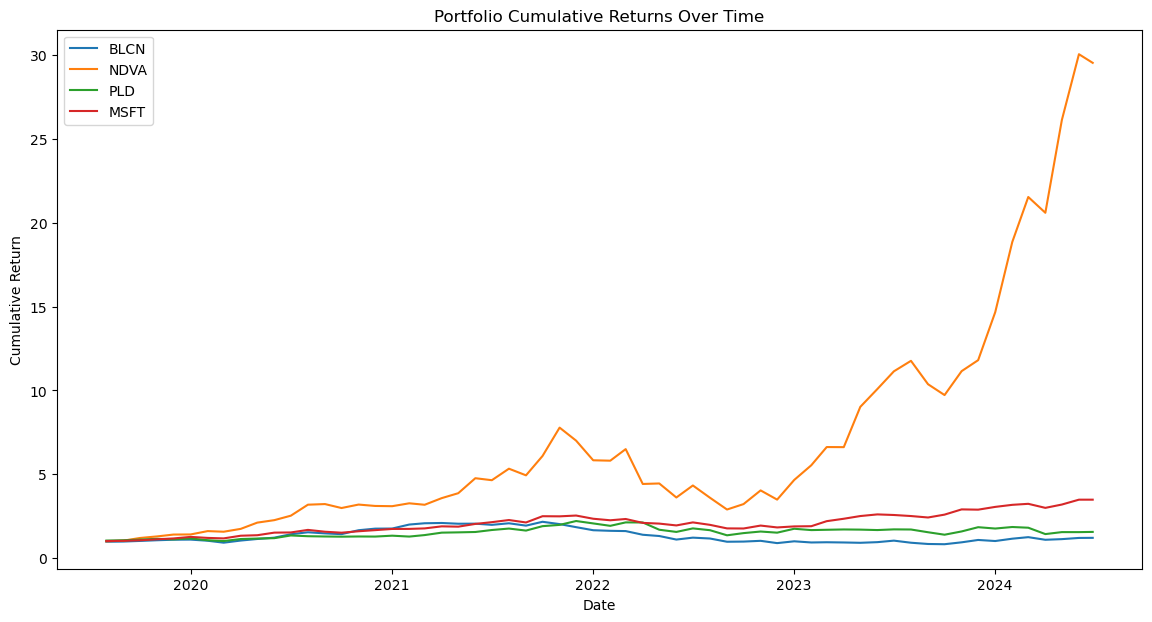

In [54]:
#plot portfolio cummulative returns
import matplotlib.pyplot as plt

# Plot the cumulative returns
plt.figure(figsize=(14, 7))

# labels for the legend
plt.plot(merged_data['Date'], merged_data['Monthly_cum_ret_BLCN'], label='BLCN')
plt.plot(merged_data['Date'], merged_data['Monthly_cum_ret_NDVA'], label='NDVA')
plt.plot(merged_data['Date'], merged_data['Monthly_cum_ret_PLD'], label='PLD')
plt.plot(merged_data['Date'], merged_data['Monthly_cum_ret_MSFT'], label='MSFT')

# Adding titles and labels
plt.title('Portfolio Cumulative Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()

# Display the plot
plt.show()

In [50]:
pf_weights=np.array([0.15,0.20,0.15,0.50])

In [83]:
# Calculate the covariance matrix of returns
pf_returns = merged_data[['BLCN_HPY_Returns', 'NDVA_HPY_Returns', 'PLD_HPY_Returns', 'MSFT_HPY_Returns']].dropna()
cov_matrix = pf_returns.cov()
# Print the formatted covariance matrix
print("\nCovariance Matrix:")
print(cov_matrix.round(2))


Covariance Matrix:
                  BLCN_HPY_Returns  NDVA_HPY_Returns  PLD_HPY_Returns  \
BLCN_HPY_Returns             74.28             71.67            44.37   
NDVA_HPY_Returns             71.67            206.50            52.23   
PLD_HPY_Returns              44.37             52.23            69.16   
MSFT_HPY_Returns             34.28             58.41            29.30   

                  MSFT_HPY_Returns  
BLCN_HPY_Returns             34.28  
NDVA_HPY_Returns             58.41  
PLD_HPY_Returns              29.30  
MSFT_HPY_Returns             39.85  


In [84]:
#calculate the covariance
Monthly_Returns=merged_data[['BLCN_Monthly_Return', 'NDVA_Monthly_Return', 'PLD_Monthly_Return', 'MSFT_Monthly_Return']].dropna()
cov_matrix=(Monthly_Returns.cov())*64
print(cov_matrix)

                     BLCN_Monthly_Return  NDVA_Monthly_Return  \
BLCN_Monthly_Return             0.475363             0.458674   
NDVA_Monthly_Return             0.458674             1.321619   
PLD_Monthly_Return              0.283950             0.334275   
MSFT_Monthly_Return             0.219384             0.373852   

                     PLD_Monthly_Return  MSFT_Monthly_Return  
BLCN_Monthly_Return            0.283950             0.219384  
NDVA_Monthly_Return            0.334275             0.373852  
PLD_Monthly_Return             0.442624             0.187523  
MSFT_Monthly_Return            0.187523             0.255054  


In [85]:
Pf_weight= np.array([0.15,0.20,0.15,0.50])

In [86]:
# Calculate the portfolio variance
pf_var = np.dot(pf_weights.T, np.dot(cov_matrix, pf_weights))

# Calculate the portfolio standard deviation (risk)
pf_std = np.sqrt(pf_var)

# Print the portfolio risk
print(f"Portfolio Variance: {pf_var:.4f}")
print(f"Portfolio Standard Deviation (Risk): {pf_std:.4f}")



Portfolio Variance: 0.3334
Portfolio Standard Deviation (Risk): 0.5774


In [87]:
#calculate the pf annualized mean return
((1+np.mean(merged_data['BLCN_HPY_Returns']))**64)-1
((1+np.mean(merged_data['NDVA_HPY_Returns']))**64)-1
((1+np.mean(merged_data['PLD_HPY_Returns']))**64)-1
((1+np.mean(merged_data['MSFT_HPY_Returns']))**64)-1


1.2921501837317735e+33

In [88]:
# Calculate the number of years
start_date = merged_data['Date'].iloc[0]
end_date = merged_data['Date'].iloc[-1]
num_years = (end_date - start_date).days  / 365.25

print (num_years)

4.988364134154689


In [91]:
# Annualize the portfolio variance and standard deviation

pf_var_annual = pf_var * num_years
pf_std_annual = pf_std * np.sqrt(pf_var_annual)

# Print the annual portfolio risk

print(f"Annual Portfolio Variance: {pf_var_annual:.2f}")
print(f"Annual Portfolio Standard Deviation (Risk): {pf_std_annual:.2f}")



Annual Portfolio Variance: 1.66
Annual Portfolio Standard Deviation (Risk): 0.74


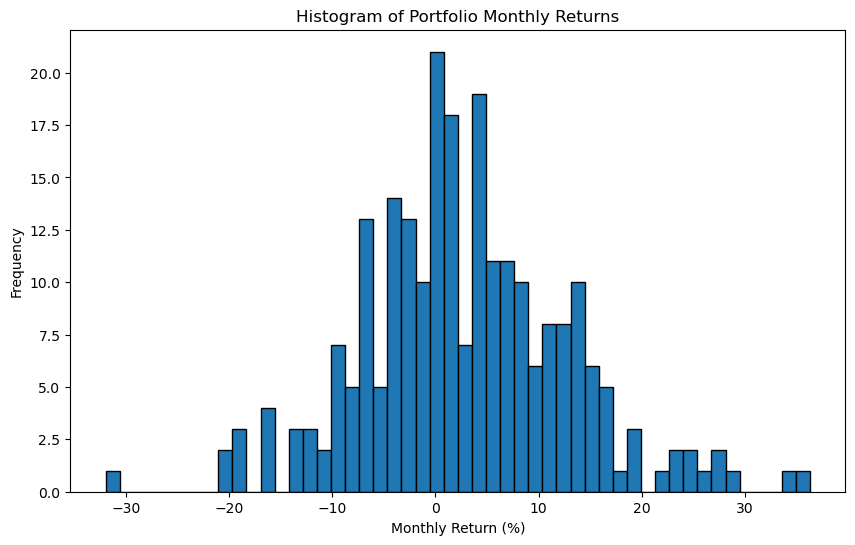

In [94]:
# Combine the returns into a single series
all_returns = pd.concat([
    merged_data['BLCN_HPY_Returns'],
    merged_data['NDVA_HPY_Returns'],
    merged_data['PLD_HPY_Returns'],
    merged_data['MSFT_HPY_Returns']
]).dropna()

# Plot the combined histogram
plt.figure(figsize=(10, 6))
plt.hist(all_returns, bins=50, edgecolor='black')
plt.title('Histogram of Portfolio Monthly Returns')
plt.xlabel('Monthly Return (%)')
plt.ylabel('Frequency')
plt.show()

In [95]:
# Calculate skewness and kurtosis
from scipy.stats import skew, kurtosis
portfolio_skewness = skew(all_returns)
portfolio_kurtosis = kurtosis(all_returns)

# Print skewness and kurtosis
print(f"Skewness of portfolio returns: {portfolio_skewness:.2f}")
print(f"Kurtosis of portfolio returns: {portfolio_kurtosis:.2f}")

Skewness of portfolio returns: 0.20
Kurtosis of portfolio returns: 0.87


Correlation Matrix:
                     BLCN_Monthly_Return  NDVA_Monthly_Return  \
BLCN_Monthly_Return             1.000000             0.578680   
NDVA_Monthly_Return             0.578680             1.000000   
PLD_Monthly_Return              0.619031             0.437052   
MSFT_Monthly_Return             0.630050             0.643917   

                     PLD_Monthly_Return  MSFT_Monthly_Return  
BLCN_Monthly_Return            0.619031             0.630050  
NDVA_Monthly_Return            0.437052             0.643917  
PLD_Monthly_Return             1.000000             0.558112  
MSFT_Monthly_Return            0.558112             1.000000  


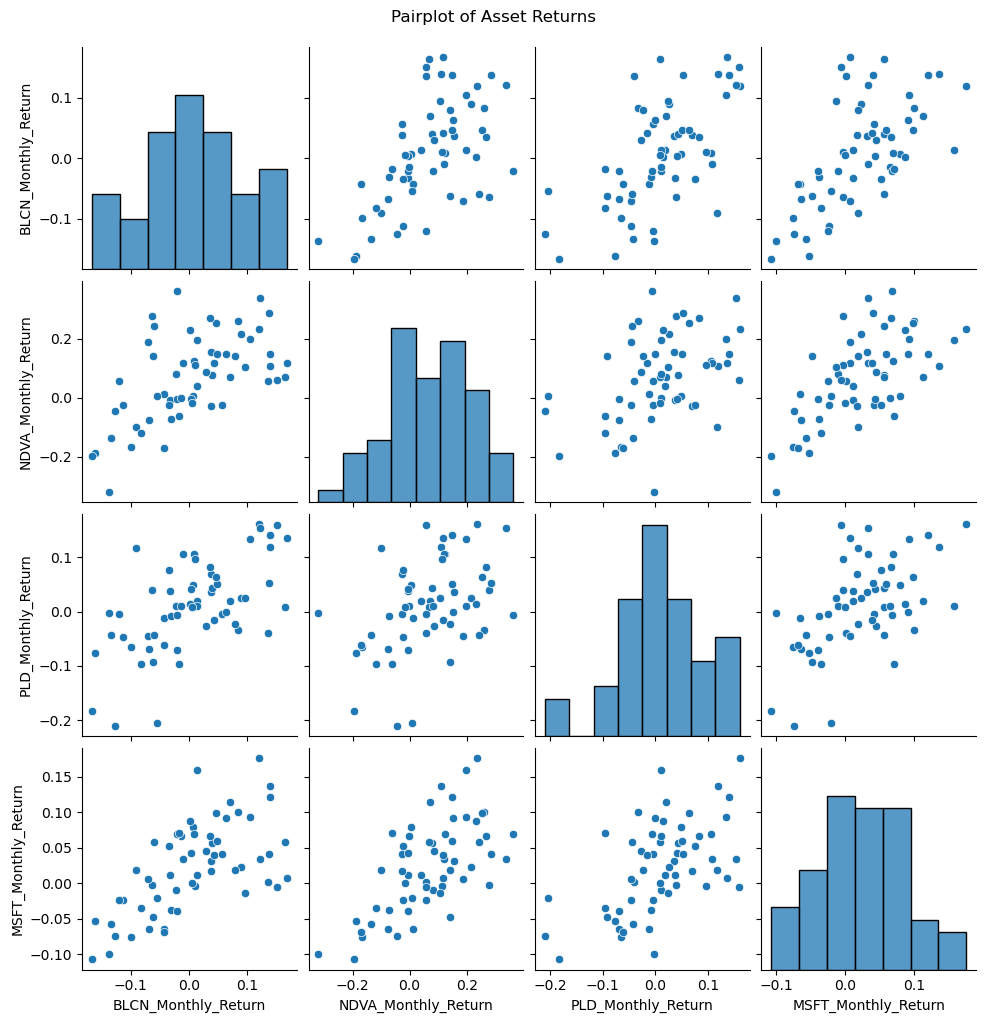

In [96]:
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = Monthly_Returns.corr()

# Print the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Plot pairplot to visualize the correlations
sns.pairplot(Monthly_Returns, diag_kind='hist')
plt.suptitle('Pairplot of Asset Returns', y=1.02)  # Adjust title position
plt.show()

In [97]:
# Prepare skewness and kurtosis data
skewness_kurtosis_data = pd.DataFrame({
    'Skewness': portfolio_skewness,
    'Kurtosis': portfolio_kurtosis
}, index=Monthly_Returns.columns)

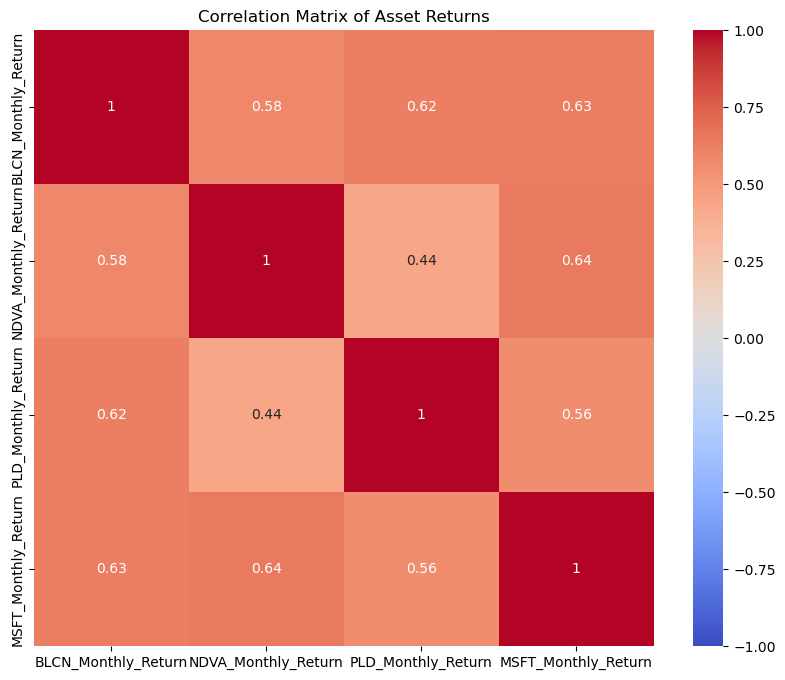

In [98]:
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Asset Returns')
plt.show()

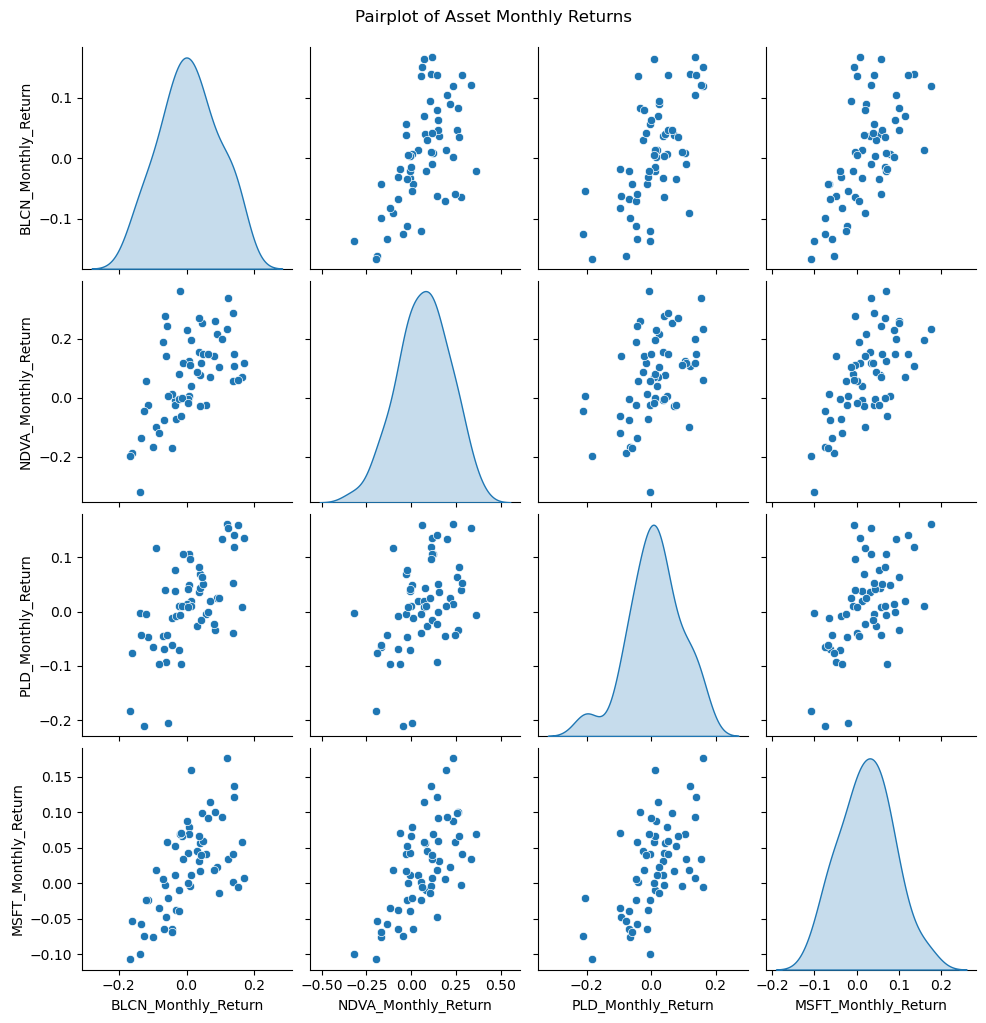

In [99]:
import seaborn as sns

# Assuming 'returns_data' contains the monthly returns
sns.pairplot(Monthly_Returns, diag_kind='kde')
plt.suptitle('Pairplot of Asset Monthly Returns', y=1.02)
plt.show()


In [100]:
# Create a Pandas Excel writer using XlsxWriter as the engine
# Install xlsxwriter
!pip install xlsxwriter
with pd.ExcelWriter('portfolio_analysis.xlsx', engine='xlsxwriter') as writer:
    # Write each DataFrame to a different worksheet
    merged_data.to_excel(writer, sheet_name='Merged Data', index=False)
    Monthly_Returns.to_excel(writer, sheet_name='Daily Returns')
    correlation_matrix.to_excel(writer, sheet_name='Correlation Matrix')
    skewness_kurtosis_data.to_excel(writer, sheet_name='Skewness Kurtosis')
 
    
    # Get the xlsxwriter workbook and worksheet objects
    workbook = writer.book
    worksheet_hist = workbook.add_worksheet('Histogram')
    worksheet_scatter = workbook.add_worksheet('Scatter Matrix')
    worksheet_cum_ret = workbook.add_worksheet('Cumulative Returns')
    
    # Insert the images into the worksheets
    worksheet_hist.insert_image('B2', 'portfolio_histogram.png')
    worksheet_scatter.insert_image('B2', 'portfolio_scatter_matrix.png')
    worksheet_cum_ret.insert_image('B2', 'cumulative_returns.png')

print("Data and plots have been successfully saved to 'portfolio_analysis.xlsx'")

Data and plots have been successfully saved to 'portfolio_analysis.xlsx'


C:\Users\Dell\anaconda3\lib\site-packages\xlsxwriter\worksheet.py:1534: UserWarning: Image file 'portfolio_histogram.png' not found.
  warn("Image file '%s' not found." % filename)
C:\Users\Dell\anaconda3\lib\site-packages\xlsxwriter\worksheet.py:1534: UserWarning: Image file 'portfolio_scatter_matrix.png' not found.
  warn("Image file '%s' not found." % filename)
C:\Users\Dell\anaconda3\lib\site-packages\xlsxwriter\worksheet.py:1534: UserWarning: Image file 'cumulative_returns.png' not found.
  warn("Image file '%s' not found." % filename)


In [101]:
import os

print("Current working directory:", os.getcwd())

Current working directory: C:\Users\Dell


In [102]:
portfolio_analysis

NameError: name 'portfolio_analysis' is not defined